In [1]:
import os
import sys, pathlib
import numpy as np

sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo','physion', 'src'))

from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.dataviz.imaging import show_CaImaging_FOV
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
#from physion.dataviz.raw import plot_test
from physion.dataviz import tools as dv_tools

import matplotlib.pyplot as plt

from scipy import stats
from physion.analysis.process_NWB import EpisodeData

base_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'NWBs')

from physion.dataviz.episodes.trial_average import plot as plot_trial_average

import random

In [16]:
# Function to generate full paths
def generate_file_paths(filenames_list, base_path):
    return [os.path.join(base_path, filename) for filename in filenames_list]

# Function to load data and process
def load_and_process_data(filenames):
    data_list = []
    for filename in filenames:
        print(filename)
        data = Data(filename, verbose=False)
        data.build_dFoF(method_for_F0='sliding_percentile',
                        verbose=False)
        data_list.append(data)
    return data_list

def process_data(data):
    data.build_dFoF(method_for_F0='sliding_percentile',
                    verbose=False)
    setattr(data, 'new', 0)
    
def get_dFoF(the_list):
    dFoF_all = []
    for data in DATA_monitoring_keta:
        dFoF_all.append(data.dFoF)
    return dFoF_all

def check_group(the_list): #prints (number ROIs, number datapoints)
    for i in range(0, len(the_list)):
        print(the_list[i].dFoF.shape)

def average_ROIs(the_list):
    list_mean_ROIs = []
    for i in range(0, len(the_list)):
        mean_ROIs = np.mean(the_list[i].dFoF, axis=0)
        list_mean_ROIs.append(mean_ROIs)
        #print(mean_ROIs)
        #print(mean_ROIs.shape)
    return list_mean_ROIs

def pad_list(n_array):
    max_length = max(len(arr) for arr in n_array)
    padded_arrays = np.array([np.pad(arr, (0, max_length - len(arr)), constant_values=np.nan) for arr in n_array])
    #print(padded_arrays.shape)
    return padded_arrays



In [17]:
names_monitoring_keta = ["2024_10_07-16-26-15.nwb", "2024_10_11-14-13-22.nwb", "2024_10_11-15-46-32.nwb", "2024_10_11-17-26-55.nwb"]
names_8ori_keta       = ["2024_09_12-14-57-34.nwb", "2024_09_12-15-24-47.nwb", "2024_09_12-15-50-12.nwb", "2024_10_07-15-03-40.nwb", 
                         "2024_10_07-17-18-53.nwb", "2024_10_11-14-57-27.nwb", "2024_10_11-16-44-26.nwb", "2024_10_11-18-24-27.nwb"]
names_8ori_saline     = ["2024_08_27-12-21-14.nwb", "2024_08_27-12-46-41.nwb"]

In [18]:
fns = generate_file_paths(names_monitoring_keta, base_path)
data = Data(fns[0], verbose=False)


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


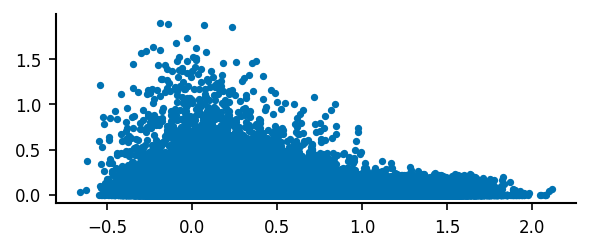

In [21]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()
running_FaceCamera_sampled = data.build_running_speed(specific_time_sampling=data.t_rawFluo)
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pt.figure(figsize=(2,2))
plt.scatter(data.dFoF[0,:], running_dFoF_sampled)


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


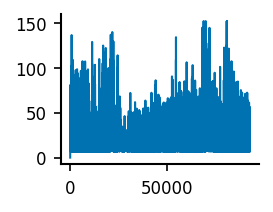

In [24]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()
data.build_facemotion()
data.facemotion
plt.plot(data.facemotion)
#running_pupil_diameter_sampled = data.build_pupil_diameter()
#running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
#pt.figure(figsize=(2,2))
#plt.scatter(data., running_dFoF_sampled)

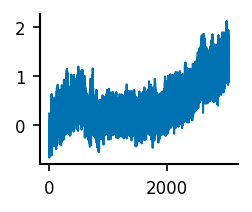

In [126]:
plt.plot(data.t_dFoF, data.dFoF[0])

(27, 89818)
89818
bin : [ 0  ;  8 ]
[1.335251   1.3859171  0.914723   0.62640136 0.50335526 0.78435236
 0.49135113 0.9752316 ]
bin : [ 8  ;  16 ]
[0.45012638 0.3574586  0.8076164  0.5935756  0.3105265  0.7758465
 0.7472024  0.00257607]
bin : [ 16  ;  24 ]
[ 0.3934586  -0.03214703  0.20171903  0.5654      0.24659002  0.19593148
  0.40656206  0.00748272]
bin : [ 24  ;  32 ]
[ 0.37946412  0.32007775  0.05357032  0.4642871   0.07822404 -0.2425177
  0.5096502  -0.06928831]
bin : [ 32  ;  40 ]
[0.05606573 0.43605512 0.08216491 0.12698668 0.01685919 0.46407786
 0.67598164 0.36163738]
bin : [ 40  ;  48 ]
[-0.06343036  0.92670655  0.26402253  0.79503244  0.42748815 -0.45431632
  0.46735352  0.12499873]
bin : [ 48  ;  56 ]
[ 0.6816923   0.21872705  0.07579201  0.50470984  0.3897434  -0.05273392
  0.2319677   1.0050851 ]
bin : [ 56  ;  64 ]
[ 0.28568867  0.14887436 -0.01238045 -0.15409727  0.02993812  0.4181768
  0.34923226  0.17943834]
bin : [ 64  ;  72 ]
[ 0.20247142 -0.05590719 -0.05872564 -0.

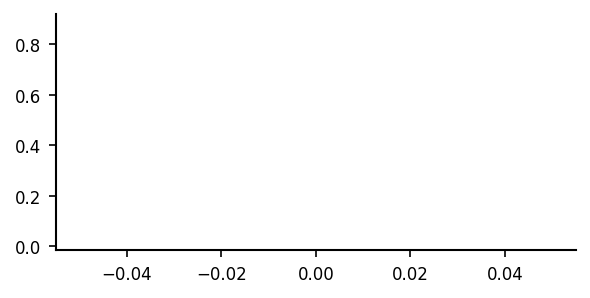

In [123]:
print(data.dFoF.shape) # (rois, time samples)
n_episodes = data.dFoF.shape[1]
bins = 40
roi = 1

print(n_episodes)
#bin_size = int(np.round(n_episodes/bins))
bin_size = 8


fig, ax = pt.figure(figsize=(2, 2.5))
for i in range(bins):
    print("bin : [", i*bin_size," ; ", (1+i)*bin_size, "]")
    print(data.dFoF[roi,i*bin_size:(1+i)*bin_size])
    temp = data.dFoF[roi,i*bin_size:(1+i)*bin_size]
    ax.plot( ,temp.mean(axis=0), color=pt.get_linear_colormap('y', 'b')(i/4))


In [7]:
data.metadata

{'config': 'Yann-A1-2P',
 'date': '2024_10_07',
 'time': '16-26-15',
 'protocol': 'injection-monitoring',
 'VisualStim': True,
 'recording': '',
 'notes': 'Ketamine injection 16:19',
 'FOV': '',
 'subject_ID': 'demo-Mouse',
 'NIdaq-acquisition-frequency': 10000,
 'NIdaq-analog-input-channels': 1,
 'NIdaq-digital-input-channels': 2,
 'Rig': 'ICM-A1-2P-setup',
 'Screen': 'Dell-2020',
 'Z-sign-correction-for-rig': -1,
 'FaceCamera-frame-rate': 30,
 'FaceCamera-1cm-in-pix': 480,
 'RigCamera-frame-rate': 20,
 'RigCamera-1cm-in-pix': 33,
 'Height-of-Microscope-Camera-Image-in-mm': 2.7,
 'rotating-disk': {'radius-position-on-disk-cm': 9.0,
  'roto-encoder-value-per-rotation': -25300.0},
 'root_datafolder': 'DATA',
 'subjects_folder': 'Yann',
 'experimenter': 'Yann Zerlaut',
 'lab': 'Rebola and Bacci labs',
 'institution': 'Institut du Cerveau et de la Moelle, Paris',
 'protocols': array(['injection-monitoring'], dtype='<U20'),
 'Locomotion': True,
 'FaceCamera': True,
 'RigCamera': False,
 'N

In [26]:
data.init_visual_stim()

In [28]:
ep = EpisodeData(data,
                 prestim_duration=2,
                 protocol_id=0,
                 quantities=['dFoF'])

  Number of episodes over the whole recording: 304/304 (with protocol condition)
  building episodes with 1 modalities [...]
  -> [ok] episodes ready !


array([[1.18567447, 1.17360515, 1.16153584, ..., 0.861436  , 0.88857036,
        0.91570471],
       [0.98474568, 1.01971101, 1.05467633, ..., 0.21331711, 0.17774822,
        0.14217933],
       [2.09872238, 2.09220179, 2.08568121, ..., 2.27974291, 2.29010282,
        2.30046274],
       ...,
       [1.99058372, 2.00163441, 2.0126851 , ..., 1.43399831, 1.41145841,
        1.38891852],
       [1.25549963, 1.2488323 , 1.24216497, ..., 3.44387721, 3.45541375,
        3.46695028],
       [1.36839985, 1.35574516, 1.34309047, ..., 2.91402032, 2.85142967,
        2.78883903]])

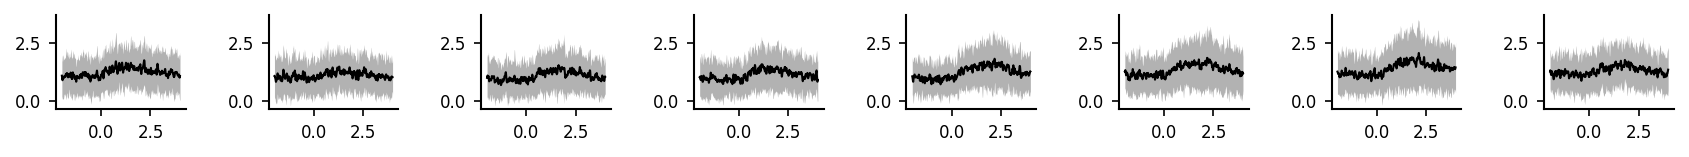

In [109]:
n_ori = 8
fig, AX = pt.figure(axes=(n_ori,1))
roi=15
for angle, ax in zip(np.unique(ep.angle), AX):
    pt.plot(ep.t, 
            ep.dFoF[ep.angle==angle, roi, :].mean(axis=0), 
            sy=ep.dFoF[ep.angle==angle, roi, :].std(axis=0), 
            #sy=stats.sem(ep.dFoF[ep.angle==angle, roi, :], axis=0), 
            ax=ax, title='%.1fdeg'%angle)
pt.set_common_ylims(AX)

#ep.dFoF[ep.angle==90, roi, :]

X-bar label automatically set to:  0.7  Using the format %.1f  --> adjust it and add units through the format !
Y-bar label automatically set to:  0.7  Using the format %.1f  --> adjust it and add units through the format !


(<Figure size 750x450 with 8 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >]], dtype=object))

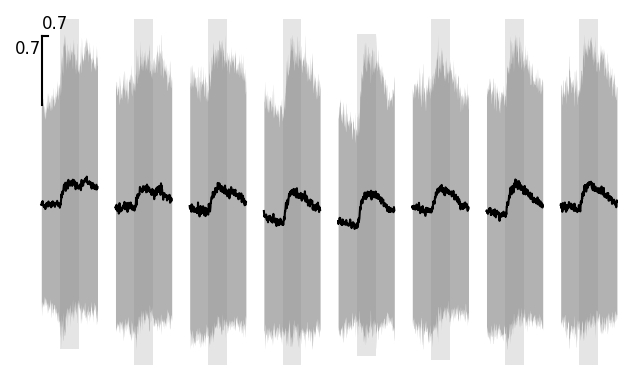

In [110]:
plot_trial_average(ep, column_key='angle')

## Plot episodes averaging with bins

In [86]:
ep = EpisodeData(data,
                 prestim_duration=2,
                 protocol_id=0,
                 quantities=['dFoF'])

  Number of episodes over the whole recording: 304/304 (with protocol condition)
  building episodes with 1 modalities [...]
  -> [ok] episodes ready !


(304, 27, 5998)
3


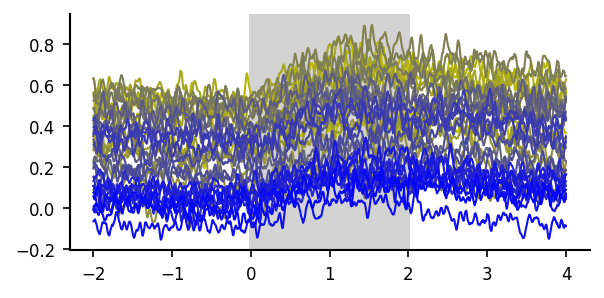

In [292]:
print(ep.dFoF.shape) # (trials, rois, time samples)
n_episodes = ep.dFoF.shape[0]
roi = 3 # random.randint(0, 26)

bin_size = 8
bins = int(n_episodes/bin_size)

norm_cond = (ep.t>-0.1) & (ep.t<0)
fig, ax = pt.figure(figsize=(2, 2.5))
print(roi)
for i in range(bins):
    #print("bin : [", i*bin_size," ; ", (1+i)*bin_size, "]")
    #temp = ep.dFoF[i*bin_size:(1+i)*bin_size,:,:].mean(axis=1).mean(axis=0)
    temp = ep.dFoF[i*bin_size:(1+i)*bin_size,roi,:].mean(axis=0)
    #ax.plot(ep.t, temp-temp[norm_cond].mean(), color=pt.get_linear_colormap('y', 'b')(i/bins))
    ax.plot(ep.t, temp, color=pt.get_linear_colormap('y', 'b')(i/bins))
    ax.axvspan(0,2, color='lightgrey') #check it's 2

(304, 27, 5998)
0
(304, 5998)


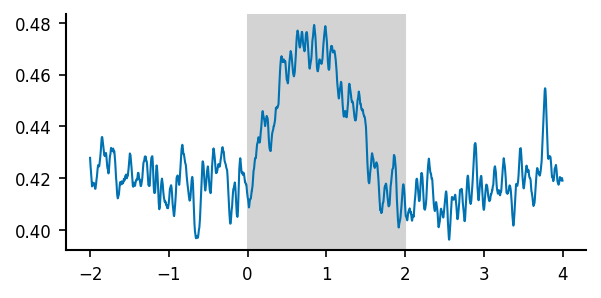

In [243]:
print(ep.dFoF.shape) # (trials, rois, time samples)
n_episodes = ep.dFoF.shape[0]
#roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly
roi=0
print(roi)

fig, ax = pt.figure(figsize=(2, 2.5))
temp = ep.dFoF[:,roi,:]
print(temp.shape)
ax.plot(ep.t, temp.mean(axis=0)) #mean of all the episodes
ax.axvspan(0,2, color='lightgrey') #check it's 2

In [259]:
def find_peak(ep, duration, roi=0):
    return ep.dFoF[:, roi, (ep.t>0) & (ep.t<duration) ].mean(axis=0).max()
    #print(np.mean(ep.dFoF[:,roi,cond], axis=0).shape)
    #portion = np.mean(ep.dFoF[:,roi,cond], axis=0)
    #max_portion = np.max(portion[start:stop])
    #return max_portion

In [260]:
find_peak(ep, duration=2, roi=0)

np.float64(0.47915186861463405)

In [258]:
tStart = 0
tStop = data.metadata['presentation-duration']

In [293]:
data = Data(fns[2], verbose=False)

In [300]:
data.build_dFoF(method_for_F0='sliding_percentile',
                verbose=True, 
                with_correctedFluo_and_F0=True, 
                percentile=10,
                sliding_window=5*60) #10min


calculating dF/F with method "sliding_percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.2s)


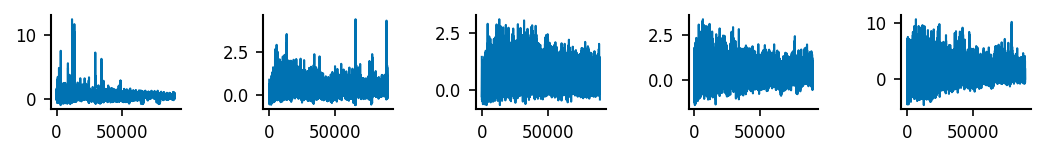

In [301]:
fig, AX = pt.figure(axes=(5,1))
for i in range(5):
    AX[i].plot(data.dFoF[i,:])